이거 그냥 트리들로 베이스라인 만든거

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import clone

import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")


In [13]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [14]:
df = pd.read_csv("./아마도최종데이터.csv")
df.head()

,Date,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield,us2y_yield,term_spread,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%,wti_mm_net_long_is_update,wti_mm_net_long_shock_raw,wti_mm_net_long_days_since_update,wti_mm_net_long_avail,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_is_update,wti_mm_net_long_ratio_shock_raw,wti_mm_net_long_ratio_days_since_update,wti_mm_net_long_ratio_avail,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_is_update,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_days_since_update,wti_producer_hedge_ratio_avail,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_is_update,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_days_since_update,wti_mm_position_change_wow_avail,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_is_update,wti_sentiment_position_shock_raw,wti_sentiment_position_days_since_update,wti_sentiment_position_avail,wti_sentiment_position_shock_decay,event_large_move,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow,wti_producer_hedge_ratio_lag3,wti_producer_hedge_ratio_lag5,spread_regime,spread_regime_code,spread_extreme,spread_chg_5d,crude_vs5_regime,crude_vs5_regime_code,crude_vs5_extreme,crude_vs5_zscore,news_total_count,clust_0_count,clust_1_count,clust_2_count,clust_3_count,clust_4_count,clust_5_count,clust_6_count,clust_7_count,clust_8_count,clust_9_count,clust_10_count,clust_11_count,clust_12_count,clust_13_count,clust_14_count,clust_15_count,clust_16_count,clust_17_count,clust_18_count,clust_19_count,clust_20_count,clust_21_count,clust_22_count,clust_23_count,clust_24_count,clust_25_count,clust_26_count,clust_27_count,clust_28_count,clust_29_count,clust_0_impact_mean,clust_1_impact_mean,clust_2_impact_mean,clust_3_impact_mean,clust_4_impact_mean,clust_5_impact_mean,clust_6_impact_mean,clust_7_impact_mean,clust_8_impact_mean,clust_9_impact_mean,clust_10_impact_mean,clust_11_impact_mean,clust_12_impact_mean,clust_13_impact_mean,clust_14_impact_mean,clust_15_impact_mean,clust_16_impact_mean,clust_17_impact_mean,clust_18_impact_mean,clust_19_impact_mean,clust_20_impact_mean,clust_21_impact_mean,clust_22_impact_mean,clust_23_impact_mean,clust_24_impact_mean,clust_25_impact_mean,clust_26_impact_mean,clust_27_impact_mean,clust_28_impact_mean,clust_29_impact_mean,clust_0_impact_sum,clust_1_impact_sum,clust_2_impact_sum,clust_3_impact_sum,clust_4_impact_sum,clust_5_impact_sum,clust_6_impact_sum,clust_7_impact_sum,clust_8_impact_sum,clust_9_impact_sum,clust_10_impact_sum,clust_11_impact_sum,clust_12_impact_sum,clust_13_impact_sum,clust_14_impact_sum,clust_15_impact_sum,clust_16_impact_sum,clust_17_impact_sum,clust_18_impact_sum,clust_19_impact_sum,clust_20_impact_sum,clust_21_impact_sum,clust_22_impact_sum,clust_23_impact_sum,clust_24_impact_sum,clust_25_impact_sum,clust_26_impact_sum,clust_27_impact_sum,clust_28_impact_sum,clust_29_impact_sum,news_emb_0,news_emb_1,news_emb_2,news_emb_3,news_emb_4,news_emb_5,news_emb_6,news_emb_7,news_emb_8,news_emb_9,news_emb_10,news_emb_11,news_emb_12,news_emb_13,news_emb_14,news_emb_15,news_emb_16,news_emb_17,news_emb_18,news_emb_19,news_emb_20,news_emb_21,news_emb_22,news_emb_23,news_emb_24,news_emb_25,news_emb_26,news_emb_27,news_emb_28,news_emb_29,news_emb_30,news_emb_31,news_emb_32,news_emb_33,news_emb_34,news_emb

In [16]:
df.keys()

Index(['Date', 'brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d',
       'brent_ret_5d', 'brent_ret_20d', 'brent_ma_5', 'brent_ma_20',
       'brent_ma_60',
       ...
       'news_emb_55', 'news_emb_56', 'news_emb_57', 'news_emb_58',
       'news_emb_59', 'news_emb_60', 'news_emb_61', 'news_emb_62',
       'news_emb_63', 'news_uuids'],
      dtype='object', length=245)

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

cols = [
    'brent_close',
    'wti_close',
    'brent_wti_spread',
    'brent_ret_1d',
    'brent_ret_5d',
    'brent_ret_20d',
    'brent_ma_5',
    'brent_ma_20',
    'brent_ma_60',
    'brent_vol_5d',
]

# 피처 subset
df_sub = df[cols].dropna().copy()

# VIF 계산용 DataFrame
vif_df = pd.DataFrame()
vif_df["feature"] = df_sub.columns
vif_df["VIF"] = [
    variance_inflation_factor(df_sub.values, i)
    for i in range(df_sub.shape[1])
]

vif_df


,feature,VIF
0,brent_close,inf
1,wti_close,inf
2,brent_wti_spread,inf
3,brent_ret_1d,1.892039
4,brent_ret_5d,2.781424
5,brent_ret_20d,3.571526
6,brent_ma_5,3737.074235
7,brent_ma_20,2373.786506
8,brent_ma_60,399.787908
9,brent_vol_5d,2.520799


In [109]:
df_final = pd.read_csv("./아마도최종데이터.csv")
df_final = df_final.sort_index()

# 타깃: 다음 날 Brent 종가
df_model = df_final.copy()
df_model["target_ret_1d"] = (df_model["brent_close"].shift(-1) / df_model["brent_close"]) - 1

In [98]:
df_lag = df_model.copy()
target_col = "target_ret_1d"


# lag를 줄 컬럼들 (예시)
lag_cols = []

# 1) 마켓/펀더멘탈 피처 중에서 일부
lag_cols += [
    "brent_ret_1d", "brent_ret_5d", "brent_vol_5d",
    "crude_stock_vs_5yr_avg", "spread_regime_code", "crude_vs5_regime_code",
    "news_total_count"
]

# 2) 뉴스 클러스터 impact_sum 계열
lag_cols += [c for c in df_lag.columns if "clust_" in c and c.endswith("_impact_sum")]

# 3) 뉴스 임베딩 (64차원) – 이건 lag 1만 먼저
lag_cols += [c for c in df_lag.columns if c.startswith("news_emb_")]

lag_cols = list(dict.fromkeys(lag_cols))  # 중복 제거

# lag 생성 함수
def add_lag_features(df, columns, lags=[1]):
    for col in columns:
        if col not in df.columns:
            continue
        for L in lags:
            df[f"{col}_lag{L}"] = df[col].shift(L)
    return df

# 일단 lag 1만 먼저 테스트
df_lag = add_lag_features(df_lag, lag_cols, lags=[1])

# 타깃 NaN, lag로 인해 생긴 앞부분 NaN 날리기
df_lag = df_lag.dropna(subset=[target_col]).copy()


In [99]:
drop_cols = [
    target_col,
    "spread_regime",
    "crude_vs5_regime",
    "news_uuids",
]

drop_cols = [c for c in drop_cols if c in df_lag.columns]

feature_cols = [c for c in df_lag.columns if c not in drop_cols]

X = df_lag[feature_cols].copy()
y = df_lag[target_col].copy()

non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("비수치형 피처 제거:", non_numeric)
    X = X.drop(columns=non_numeric)
    feature_cols = X.columns.tolist()

비수치형 피처 제거: ['Date']


In [100]:
X.drop('news_uuids', axis=1, inplace=True, errors='ignore')

In [101]:
# 타깃 shift(-1) 때문에 마지막 날이 NaN, 
# 초반부에 일부 파생변수 NaN 있을 수 있어서 통째로 dropna
data = pd.concat([X, y], axis=1).dropna()

X = data[feature_cols]
y = data[target_col]


In [102]:
def train_test_split_time_series(
    X, y, test_size_ratio=0.2, normalize_columns=True
):
    # 1) 컬럼명 정규화
    if normalize_columns:
        X = X.copy()
        X.columns = [
            re.sub(r'[^A-Za-z0-9_]+', '_', col)
            for col in X.columns
        ]
    
    # 2) 시계열 분할
    n = len(X)
    test_size = int(n * test_size_ratio)
    train_size = n - test_size

    X_train = X.iloc[:train_size].copy()
    y_train = y.iloc[:train_size].copy()
    X_test  = X.iloc[train_size:].copy()
    y_test  = y.iloc[train_size:].copy()

    return X_train, X_test, y_train, y_test


# 사용
X_train, X_test, y_train, y_test = train_test_split_time_series(X, y)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Sample columns:", X_train.columns[:5])


Train size: (2387, 342) Test size: (596, 342)
Sample columns: Index(['brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d',
       'brent_ret_5d'],
      dtype='object')


In [103]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

# RandomForest
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# GradientBoosting
gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

# LightGBM
lgbm = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.015,
    max_depth=-1,       # Leaf-wise best
    num_leaves=63,      # 적절한 leaf 수
    subsample=0.8,      # bagging
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# CatBoost
cat = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
cat.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49230
[LightGBM] [Info] Number of data points in the train set: 2387, number of used features: 333
[LightGBM] [Info] Start training from score 0.000186


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100


# # 이건 타겟이 종가일때
def directional_accuracy_price(y_true, y_pred):
    """
    y_true, y_pred: '내일 종가'(price) 시계열
    방향성 = 어제 대비 내일이 오르냐/내리냐를 맞췄는지
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # 길이 체크
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    # 어제 종가 (t-1)
    prev_true = np.roll(y_true, 1)
    prev_true[0] = np.nan  # 첫 값은 기준 없음

    true_dir = np.sign(y_true - prev_true)   # 실제 방향
    pred_dir = np.sign(y_pred - prev_true)   # 예측 방향

    # NaN 제거 + 변화 없는 날(0) 제거
    mask = ~np.isnan(prev_true) & (true_dir != 0)
    if mask.sum() == 0:
        return np.nan

    return (true_dir[mask] == pred_dir[mask]).mean()

# 이건 타겟이 수익률일때
def directional_accuracy_return(y_true, y_pred):
    """
    y_true, y_pred: '내일 수익률'(return)
    방향성 = 수익률 부호(sign)를 맞췄는지
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)

    mask = (true_dir != 0)
    if mask.sum() == 0:
        return np.nan

    return (true_dir[mask] == pred_dir[mask]).mean()


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, target_type="return"):
    # 예측
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    
    # RMSE (직접 sqrt)
    mse_tr  = mean_squared_error(y_tr, pred_tr)
    mse_te  = mean_squared_error(y_te, pred_te)
    rmse_tr = np.sqrt(mse_tr)
    rmse_te = np.sqrt(mse_te)

    # MAE
    mae_tr  = mean_absolute_error(y_tr, pred_tr)
    mae_te  = mean_absolute_error(y_te, pred_te)


    # 방향성
    if target_type == "price":
        dir_tr = directional_accuracy_price(y_tr, pred_tr)
        dir_te = directional_accuracy_price(y_te, pred_te)
    else:  # "return"
        dir_tr = directional_accuracy_return(y_tr, pred_tr)
        dir_te = directional_accuracy_return(y_te, pred_te)
    
    print(f"\n[{name}]")
    print("Train - RMSE: {:.4f}, MAE: {:.4f}, DirAcc: {:.3f}".format(
        rmse_tr, mae_tr, dir_tr
    ))
    print("Test  - RMSE: {:.4f}, MAE: {:.4f}, DirAcc: {:.3f}".format(
        rmse_te, mae_te, dir_te
    ))
    
    return {
        "pred_train": pred_tr,
        "pred_test": pred_te,
    }


In [107]:
# 타깃이 내일 수익률이면 (예: brent_ret_1d_next)
rf_res   = evaluate_model("RandomForest",       rf,   X_train, y_train, X_test, y_test,
                          target_type="price")
gb_res   = evaluate_model("GradientBoosting",   gb,   X_train, y_train, X_test, y_test,
                          target_type="price")
lgbm_res = evaluate_model("LightGBM",           lgbm, X_train, y_train, X_test, y_test,
                          target_type="price")
cat_res  = evaluate_model("CatBoost",           cat,  X_train, y_train, X_test, y_test,
                          target_type="price")



[RandomForest]
Train - RMSE: 0.0220, MAE: 0.0159, DirAcc: 0.764
Test  - RMSE: 0.0409, MAE: 0.0360, DirAcc: 0.571

[GradientBoosting]
Train - RMSE: 0.0160, MAE: 0.0121, DirAcc: 0.821
Test  - RMSE: 0.0380, MAE: 0.0332, DirAcc: 0.576

[LightGBM]
Train - RMSE: 0.0058, MAE: 0.0020, DirAcc: 0.987
Test  - RMSE: 0.0381, MAE: 0.0334, DirAcc: 0.575

[CatBoost]
Train - RMSE: 0.0120, MAE: 0.0091, DirAcc: 0.876
Test  - RMSE: 0.0247, MAE: 0.0200, DirAcc: 0.637


In [117]:
def evaluate_as_price_from_return(
    name,
    y_ret_tr, y_ret_te,        # y_train, y_test (수익률 타깃)
    pred_ret_tr, pred_ret_te,  # 모델 예측 수익률
    price_series               # df_model["brent_close"]
):
    """
    y_ret_* : (t 시점 기준) '내일 수익률' 시계열
    price_series : 전체 brent_close 시계열 (df_model["brent_close"])
    """
    # 인덱스 기준으로 today / next price 정렬
    price_today_tr = price_series.loc[y_ret_tr.index]              # P_t
    price_today_te = price_series.loc[y_ret_te.index]              # P_t

    true_price_next_tr = price_series.shift(-1).loc[y_ret_tr.index]  # P_{t+1}
    true_price_next_te = price_series.shift(-1).loc[y_ret_te.index]  # P_{t+1}

    # 예측한 '내일 종가' = 오늘 종가 * (1 + 예측 수익률)
    pred_price_tr = price_today_tr * (1.0 + pred_ret_tr)
    pred_price_te = price_today_te * (1.0 + pred_ret_te)

    # RMSE / MAE (가격 기준)
    rmse_tr = np.sqrt(mean_squared_error(true_price_next_tr, pred_price_tr))
    rmse_te = np.sqrt(mean_squared_error(true_price_next_te, pred_price_te))

    mae_tr = mean_absolute_error(true_price_next_tr, pred_price_tr)
    mae_te = mean_absolute_error(true_price_next_te, pred_price_te)

    # MAPE (가격 기준)
    mape_tr = calc_mape(true_price_next_tr, pred_price_tr)
    mape_te = calc_mape(true_price_next_te, pred_price_te)

    # 방향성: 사실 수익률 부호랑 동일하므로 기존 함수 재사용 가능
    dir_tr = directional_accuracy_return(y_ret_tr, pred_ret_tr)
    dir_te = directional_accuracy_return(y_ret_te, pred_ret_te)

    print(f"\n[Price Eval from Return] {name}")
    print("Train - RMSE: {:.4f}, MAE: {:.4f}, MAPE: {:.2f}%, DirAcc: {:.3f}".format(
        rmse_tr, mae_tr, mape_tr, dir_tr
    ))
    print("Test  - RMSE: {:.4f}, MAE: {:.4f}, MAPE: {:.2f}%, DirAcc: {:.3f}".format(
        rmse_te, mae_te, mape_te, dir_te
    ))

    return {
        "true_price_train": true_price_next_tr,
        "true_price_test":  true_price_next_te,
        "pred_price_train": pred_price_tr,
        "pred_price_test":  pred_price_te,
    }


# 1) 수익률 기준 평가 (기존 함수 그대로 사용)
rf_res   = evaluate_model("RandomForest",     rf,   X_train, y_train, X_test, y_test,
                          target_type="return")
gb_res   = evaluate_model("GradientBoosting", gb,   X_train, y_train, X_test, y_test,
                          target_type="return")
lgbm_res = evaluate_model("LightGBM",         lgbm, X_train, y_train, X_test, y_test,
                          target_type="return")
cat_res  = evaluate_model("CatBoost",         cat,  X_train, y_train, X_test, y_test,
                          target_type="return")


# 2) 가격 기준 평가 (수익률 → 가격 변환)
price_series = df_model["brent_close"]  # 인덱스가 y_train / y_test랑 같다고 가정

rf_price_eval = evaluate_as_price_from_return(
    "RandomForest",
    y_train, y_test,
    rf_res["pred_train"], rf_res["pred_test"],
    price_series,
)

gb_price_eval = evaluate_as_price_from_return(
    "GradientBoosting",
    y_train, y_test,
    gb_res["pred_train"], gb_res["pred_test"],
    price_series,
)

lgbm_price_eval = evaluate_as_price_from_return(
    "LightGBM",
    y_train, y_test,
    lgbm_res["pred_train"], lgbm_res["pred_test"],
    price_series,
)

cat_price_eval = evaluate_as_price_from_return(
    "CatBoost",
    y_train, y_test,
    cat_res["pred_train"], cat_res["pred_test"],
    price_series,
)



[RandomForest]
Train - RMSE: 0.0220, MAE: 0.0159, DirAcc: 0.606
Test  - RMSE: 0.0409, MAE: 0.0360, DirAcc: 0.502

[GradientBoosting]
Train - RMSE: 0.0160, MAE: 0.0121, DirAcc: 0.765
Test  - RMSE: 0.0380, MAE: 0.0332, DirAcc: 0.508

[LightGBM]
Train - RMSE: 0.0058, MAE: 0.0020, DirAcc: 0.979
Test  - RMSE: 0.0381, MAE: 0.0334, DirAcc: 0.505

[CatBoost]
Train - RMSE: 0.0120, MAE: 0.0091, DirAcc: 0.865
Test  - RMSE: 0.0247, MAE: 0.0200, DirAcc: 0.513

[Price Eval from Return] RandomForest
Train - RMSE: 1.4723, MAE: 1.0272, MAPE: 1.60%, DirAcc: 0.606
Test  - RMSE: 3.1188, MAE: 2.7361, MAPE: 3.58%, DirAcc: 0.502

[Price Eval from Return] GradientBoosting
Train - RMSE: 1.0743, MAE: 0.7886, MAPE: 1.21%, DirAcc: 0.765
Test  - RMSE: 2.8735, MAE: 2.5112, MAPE: 3.30%, DirAcc: 0.508

[Price Eval from Return] LightGBM
Train - RMSE: 0.2864, MAE: 0.1137, MAPE: 0.20%, DirAcc: 0.979
Test  - RMSE: 2.8710, MAE: 2.5282, MAPE: 3.32%, DirAcc: 0.505

[Price Eval from Return] CatBoost
Train - RMSE: 0.8142, MA

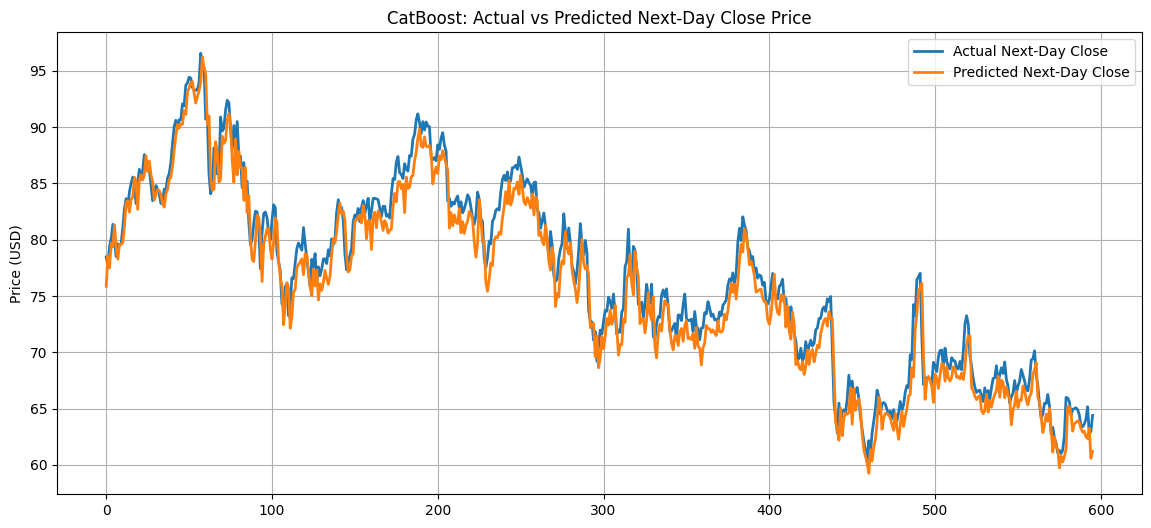

In [111]:
# 1) 오늘 종가
close_today = df_model.loc[y_test.index, "brent_close"]

# 2) 내일 종가 복원 (ret 정의는 target_ret_1d = (close_next/close_today)-1 인 걸로 가정)
y_pred_cat = cat.predict(X_test)

actual_close_next = close_today * (1 + y_test.values)
pred_close_next   = close_today * (1 + y_pred_cat)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(actual_close_next.values, label="Actual Next-Day Close", linewidth=2)
plt.plot(pred_close_next.values,  label="Predicted Next-Day Close", linewidth=2)
plt.title("CatBoost: Actual vs Predicted Next-Day Close Price")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()

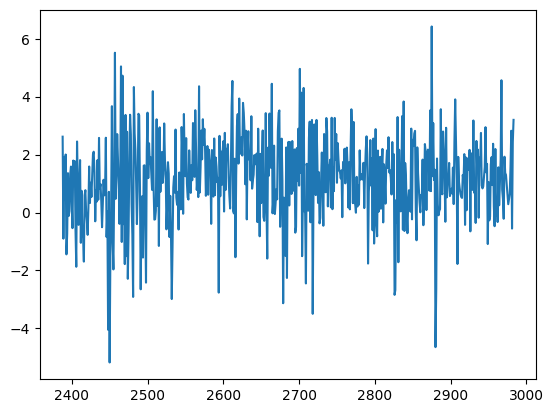

In [114]:
residual_price = actual_close_next - pred_close_next
plt.plot(residual_price)


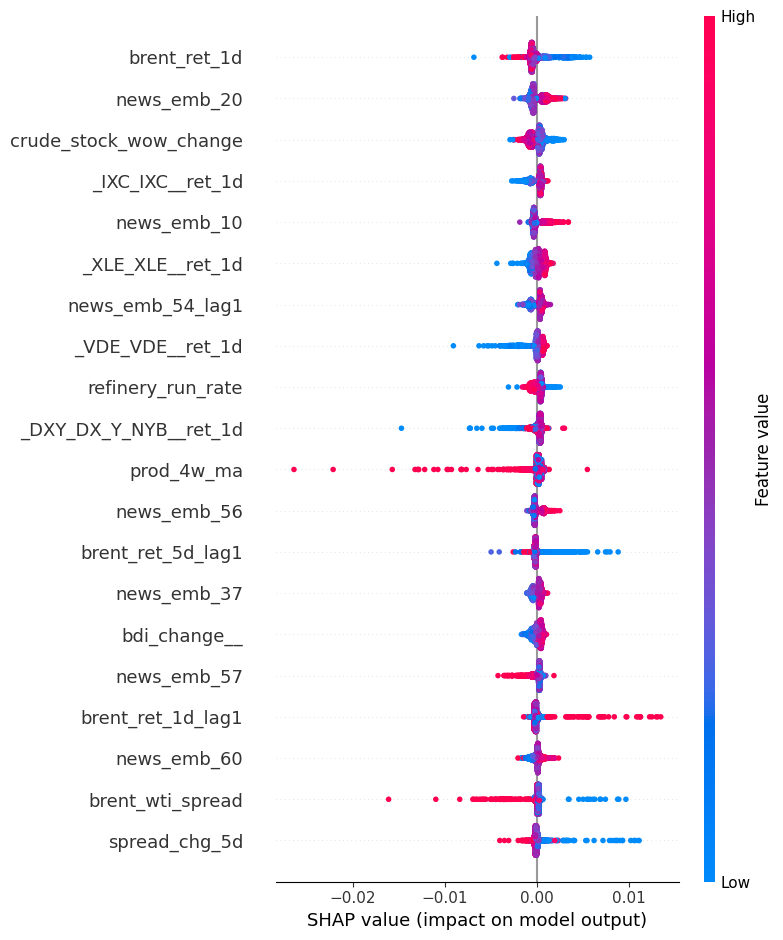

                    feature  mean_abs_shap
3              brent_ret_1d       0.000794
197             news_emb_20       0.000661
14   crude_stock_wow_change       0.000624
40         _IXC_IXC__ret_1d       0.000522
187             news_emb_10       0.000509
38         _XLE_XLE__ret_1d       0.000508
332        news_emb_54_lag1       0.000504
39         _VDE_VDE__ret_1d       0.000449
27        refinery_run_rate       0.000436
37    _DXY_DX_Y_NYB__ret_1d       0.000425
21               prod_4w_ma       0.000399
233             news_emb_56       0.000395
242       brent_ret_5d_lag1       0.000384
214             news_emb_37       0.000373
48             bdi_change__       0.000363
234             news_emb_57       0.000356
241       brent_ret_1d_lag1       0.000333
237             news_emb_60       0.000317
2          brent_wti_spread       0.000297
82            spread_chg_5d       0.000282


In [72]:
import shap

# 1) SHAP 초기화 (한 번만)
#   - CatBoostRegressor는 바로 TreeExplainer로 넣어도 됩니다.
explainer = shap.TreeExplainer(cat)

# 2) SHAP 값 계산 (train 기준)
shap_values = explainer.shap_values(X_train)

# 3) summary plot (주요 피처 직관적으로 보기)
shap.summary_plot(shap_values, X_train, max_display=20)

# 4) mean(|SHAP|) 기준으로 중요도 테이블 만들기
shap_importance = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(shap_importance.head(20))


In [73]:
def get_lgbm_importance(model, X):
    booster = model.booster_  # LGBMRegressor 안의 Booster 객체
    gain = booster.feature_importance(importance_type='gain')
    split = booster.feature_importance(importance_type='split')
    
    imp_df = pd.DataFrame({
        "feature": X.columns,
        "gain": gain,
        "split": split
    }).sort_values("gain", ascending=False)
    return imp_df

lgbm_importance = get_lgbm_importance(lgbm, X_train)
print(lgbm_importance.head(20))


                    feature      gain  split
10           high_low_range  1.980812   1339
6                brent_ma_5  1.451406    651
21               prod_4w_ma  1.218918    450
241       brent_ret_1d_lag1  1.130004    800
5             brent_ret_20d  0.977596    923
3              brent_ret_1d  0.975866    940
4              brent_ret_5d  0.837925    882
242       brent_ret_5d_lag1  0.829325    789
82            spread_chg_5d  0.740271    782
243       brent_vol_5d_lag1  0.738068    717
9              brent_vol_5d  0.719206    746
41              us10y_yield  0.718804    449
0               brent_close  0.699703    648
2          brent_wti_spread  0.666629    578
37    _DXY_DX_Y_NYB__ret_1d  0.617675    626
1                 wti_close  0.601569    519
14   crude_stock_wow_change  0.491725    406
12          gas_stock_level  0.468354    349
7               brent_ma_20  0.420862    351
325        news_emb_47_lag1  0.412880    262


In [67]:
from pmdarima import auto_arima

# ARIMA는 y 시리즈만 필요 (train 시기만 사용)
arima_model = auto_arima(
    y_train,
    seasonal=False,
    trace=False,
    error_action="ignore",
    suppress_warnings=True
)

# 전체 기간에 대해 예측 생성 (walk-forward 느낌)
arima_pred_train = arima_model.predict_in_sample()
arima_pred_test = arima_model.predict(n_periods=len(y_test))

print(len(arima_pred_train), len(arima_pred_test))


2387 596


In [90]:
# Train stacking 입력
stack_train = pd.DataFrame({
    #"rf":     rf_res["pred_train"],
    #"gb":     gb_res["pred_train"],
    "lgbm":   lgbm_res["pred_train"],
    "cat":    cat_res["pred_train"],
    #"arima":  arima_pred_train,
}, index=y_train.index)

# Test stacking 입력
stack_test = pd.DataFrame({
    #"rf":     rf_res["pred_test"],
    #"gb":     gb_res["pred_test"],
    "lgbm":   lgbm_res["pred_test"],
    "cat":    cat_res["pred_test"],
    #"arima":  arima_pred_test,
}, index=y_test.index)


In [91]:
meta = CatBoostRegressor(
    depth=5,
    learning_rate=0.03,
    n_estimators=1000,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

meta.fit(stack_train, y_train)
meta_pred_train = meta.predict(stack_train)
meta_pred_test  = meta.predict(stack_test)


In [92]:
def evaluate_meta_model(name, y_train, pred_train, y_test, pred_test):
    # Train metrics
    rmse_tr = np.sqrt(mean_squared_error(y_train, pred_train))
    mae_tr  = mean_absolute_error(y_train, pred_train)
    mape_tr = calc_mape(y_train, pred_train)
    dir_tr  = directional_accuracy_return(y_train, pred_train)

    # Test metrics
    rmse_te = np.sqrt(mean_squared_error(y_test, pred_test))
    mae_te  = mean_absolute_error(y_test, pred_test)
    mape_te = calc_mape(y_test, pred_test)
    dir_te  = directional_accuracy_return(y_test, pred_test)

    print(f"\n[{name}]")
    print("Train - RMSE: {:.4f}, MAE: {:.4f}, MAPE: {:.2f}%, DirAcc: {:.3f}".format(
        rmse_tr, mae_tr, mape_tr, dir_tr
    ))
    print("Test  - RMSE: {:.4f}, MAE: {:.4f}, MAPE: {:.2f}%, DirAcc: {:.3f}".format(
        rmse_te, mae_te, mape_te, dir_te
    ))


In [93]:
from sklearn.linear_model import Ridge

# 1) 베이스 모델 예측값 만들기
# rf_pred_train = rf.predict(X_train)
# rf_pred_test  = rf.predict(X_test)

# gb_pred_train = gb.predict(X_train)
# gb_pred_test  = gb.predict(X_test)

lgb_pred_train = lgbm.predict(X_train)
lgb_pred_test  = lgbm.predict(X_test)

cb_pred_train = cat.predict(X_train)
cb_pred_test  = cat.predict(X_test)

# ar_pred_train = arima_model.predict(X_train)
# ar_pred_test  = arima_model.predict(X_test)

# 2) 메타 모델 입력 행렬 만들기 (열 = 각 베이스 모델의 예측)
meta_X_train = np.vstack([
    #rf_pred_train,
    #gb_pred_train,
    lgb_pred_train,
    cb_pred_train
]).T  # shape: (n_train, 4)

meta_X_test = np.vstack([
    #rf_pred_test,
    #gb_pred_test,
    lgb_pred_test,
    cb_pred_test
]).T  # shape: (n_test, 4)

# 3) 메타 모델 학습 (Ridge 예시)
meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(meta_X_train, y_train)

# 4) 메타 예측값
meta_pred_train = meta_model.predict(meta_X_train)
meta_pred_test  = meta_model.predict(meta_X_test)

# 5) 메타 모델 평가
evaluate_meta_model(
    "Stacking Meta Model",
    y_train,
    meta_pred_train,
    y_test,
    meta_pred_test
)



[Stacking Meta Model]
Train - RMSE: 0.0101, MAE: 0.0068, MAPE: 57.99%, DirAcc: 0.955
Test  - RMSE: 0.0282, MAE: 0.0238, MAPE: 544.79%, DirAcc: 0.510
